In [1]:
#!/usr/bin/env python3
"""
PARSeq + auxiliary CTC head — single-file OCR for 1/2/3-line number plates.

WHY TWO HEADS
-------------
A pure autoregressive decoder can drive its loss down by modelling
p(next char | previous chars) and barely reading the image — plates are highly
structured, so the label prior alone gets you far. The result fits the training
set and hallucinates plausible plates on unseen ones.

The CTC head prevents that. It is forced to emit characters in raster order
along the flattened feature grid, which is only possible if the encoder
produces per-character, positionally-localised features. It supplies the
monotonic alignment prior that makes CNN+LSTM+CTC generalise so well, for the
price of one linear layer.

The PARSeq decoder then handles what CTC cannot: 2- and 3-line layouts, where
it attends anywhere in 2D and does not care about reading order at all. It is
also trained with Permutation Language Modelling, so no single scan order can
become a crutch, and it refines its output with a bidirectional cloze pass.

    total loss = parseq_loss + ctc_weight * ctc_loss     (decode with PARSeq)

MULTI-LINE + CTC
----------------
Flatten the encoder grid in raster order and every token of line 1 precedes
every token of line 2, so a valid monotonic CTC path exists (this is the
OrigamiNet idea). The failure mode is a line firing in two row bands at once
("GJ06GJ06" — CTC only collapses *adjacent* duplicates), so the grid is pooled
down to `ctc_bands` rows before the CTC head, leaving little room to double
fire.

LABEL ORDER
-----------
The CTC head requires ground-truth text in raster reading order: a plate
reading "GJ06" / "AB1234" must be stored as "GJ06AB1234". If ctc_loss plateaus
high while parseq_loss falls, your labels are not in reading order — set
--ctc-weight 0 and the model still trains (as plain PARSeq).

USAGE
-----
  python parseq_ctc_ocr.py train    --root DATASET_DIR --manifest manifest.jsonl
  python parseq_ctc_ocr.py predict  --ckpt parseq_ctc.pt --image plate.png
  python parseq_ctc_ocr.py diagnose --ckpt parseq_ctc.pt   # is it reading pixels?

Manifest: one JSON object per line, {"color": "images/0001.png", "text": "GJ06AB1234"}
"""

from __future__ import annotations

import argparse
import json
import math
import os
import random
from dataclasses import asdict, dataclass
from itertools import permutations

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(x, **kw):
        return x


# =====================================================================
# 1. CONFIG
# =====================================================================
@dataclass
class Config:
    # ---- data ----
    charset: str = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    img_h: int = 96                 # taller than single-line setups: a 3-line
    img_w: int = 128                # plate needs vertical room to survive /8
    keep_aspect: bool = True        # letterbox; preserves the 1/2/3-line layout cue
    max_label_length: int = 16
    img_key: str = "color"
    text_key: str = "text"

    # ---- model ----
    embed_dim: int = 192
    enc_depth: int = 4
    enc_heads: int = 3
    dec_heads: int = 3
    mlp_ratio: float = 3.0
    dropout: float = 0.1

    # ---- permutation language modelling ----
    max_gen_perms: int = 6          # K in the paper
    perm_mirrored: bool = True
    refine_iters: int = 1           # cloze refinement passes at inference

    # ---- auxiliary CTC head ----
    ctc_weight: float = 0.2         # 0.0 disables it entirely
    ctc_bands: int = 4              # grid rows kept before the CTC head

    # ---- training ----
    epochs: int = 40
    batch_size: int = 64
    lr: float = 7e-4
    weight_decay: float = 0.01
    label_smoothing: float = 0.1
    val_split: float = 0.05
    num_workers: int = 4
    seed: int = 42


# =====================================================================
# 2. TOKENIZER
# =====================================================================
class Tokenizer:
    """
    Shared id space for both heads:
        0        -> [EOS] for the decoder, <blank> for CTC (same slot, both
                    mean "nothing to emit", so one head size fits both)
        1 .. N   -> charset
        N+1      -> [BOS]  (decoder input only)
        N+2      -> [PAD]  (decoder input only, ignored by the loss)
    The head predicts only ids 0..N.
    """

    def __init__(self, charset: str, max_label_length: int):
        self.itos = ["[E]"] + list(charset) + ["[B]", "[P]"]
        self.stoi = {c: i for i, c in enumerate(self.itos)}
        self.eos_id = 0
        self.blank_id = 0
        self.bos_id = len(self.itos) - 2
        self.pad_id = len(self.itos) - 1
        self.num_classes = len(charset) + 1
        self.max_label_length = max_label_length

    def clean(self, text: str) -> str:
        text = "".join(c for c in text.upper() if c in self.stoi)
        return text[: self.max_label_length]

    def encode(self, labels: list[str], device=None) -> torch.Tensor:
        """-> (B, L+2): [BOS] chars... [EOS] [PAD]...  (L = longest in batch)."""
        L = max(1, max(len(s) for s in labels))
        rows = []
        for s in labels:
            ids = [self.bos_id] + [self.stoi[c] for c in s] + [self.eos_id]
            ids += [self.pad_id] * (L + 2 - len(ids))
            rows.append(ids)
        return torch.tensor(rows, dtype=torch.long, device=device)

    def encode_ctc(self, labels: list[str], device=None):
        """-> flat targets (sum of lengths,) and their lengths (B,)."""
        flat = [self.stoi[c] for s in labels for c in s]
        lens = [len(s) for s in labels]
        return (torch.tensor(flat, dtype=torch.long, device=device),
                torch.tensor(lens, dtype=torch.long, device=device))

    def decode(self, ids: list[int]) -> str:
        """Decoder output: stop at the first [EOS]."""
        out = []
        for i in ids:
            if i == self.eos_id:
                break
            if i < len(self.itos) and i not in (self.bos_id, self.pad_id):
                out.append(self.itos[i])
        return "".join(out)

    def decode_ctc(self, ids: list[int]) -> str:
        """CTC output: collapse adjacent duplicates, then drop blanks."""
        out, prev = [], -1
        for i in ids:
            if i != prev and i != self.blank_id:
                out.append(self.itos[i])
            prev = i
        return "".join(out)


# =====================================================================
# 3. DATA
# =====================================================================
def augment(img: np.ndarray) -> np.ndarray:
    """Geometric + photometric augmentation. On a synthetic-only training set
    this is worth more than any architectural change."""
    h, w = img.shape[:2]

    if random.random() < 0.7:                      # perspective / tilt
        m = 0.06
        src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
        dst = src + np.float32([[random.uniform(-m, m) * w,
                                 random.uniform(-m, m) * h] for _ in range(4)])
        M = cv2.getPerspectiveTransform(src, dst)
        img = cv2.warpPerspective(img, M, (w, h), borderMode=cv2.BORDER_REPLICATE)

    if random.random() < 0.7:                      # contrast / brightness
        img = cv2.convertScaleAbs(img, alpha=random.uniform(0.7, 1.3),
                                  beta=random.uniform(-30, 30))
    if random.random() < 0.3:                      # gamma
        g = random.uniform(0.6, 1.6)
        lut = np.clip((np.arange(256) / 255.0) ** g * 255, 0, 255).astype(np.uint8)
        img = cv2.LUT(img, lut)

    r = random.random()                            # capture degradation
    if r < 0.25:
        k = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (k, k), 0)
    elif r < 0.40:                                 # resolution loss
        s = random.uniform(0.35, 0.8)
        small = cv2.resize(img, (max(4, int(w * s)), max(4, int(h * s))),
                           interpolation=cv2.INTER_AREA)
        img = cv2.resize(small, (w, h), interpolation=cv2.INTER_LINEAR)
    elif r < 0.55:                                 # motion blur
        k = random.choice([5, 7])
        kern = np.zeros((k, k), np.float32)
        kern[k // 2, :] = 1.0 / k
        img = cv2.filter2D(img, -1, kern.T if random.random() < 0.5 else kern)

    if random.random() < 0.3:                      # sensor noise
        noise = np.random.normal(0, random.uniform(4, 14), img.shape)
        img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    if random.random() < 0.3:                      # jpeg artefacts
        _, enc = cv2.imencode(".jpg", img,
                              [int(cv2.IMWRITE_JPEG_QUALITY), random.randint(25, 75)])
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)
    if random.random() < 0.15:                     # grayscale cameras
        img = cv2.cvtColor(cv2.cvtColor(img, cv2.COLOR_RGB2GRAY), cv2.COLOR_GRAY2RGB)
    return img


def preprocess(img: np.ndarray, cfg: Config) -> torch.Tensor:
    """RGB uint8 HWC -> float CHW in [-1, 1], sized (img_h, img_w)."""
    H, W = cfg.img_h, cfg.img_w
    if cfg.keep_aspect:
        h, w = img.shape[:2]
        s = min(W / w, H / h)
        nw, nh = max(1, int(w * s)), max(1, int(h * s))
        resized = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_AREA
                             if s < 1 else cv2.INTER_LINEAR)
        canvas = np.zeros((H, W, 3), np.uint8)
        y, x = (H - nh) // 2, (W - nw) // 2
        canvas[y:y + nh, x:x + nw] = resized
        img = canvas
    else:
        img = cv2.resize(img, (W, H), interpolation=cv2.INTER_LINEAR)
    x = (img.astype(np.float32) / 255.0 - 0.5) / 0.5
    return torch.from_numpy(x.transpose(2, 0, 1))


class PlateDataset(Dataset):
    def __init__(self, root, samples, cfg: Config, train: bool):
        self.root, self.samples, self.cfg, self.train = root, samples, cfg, train

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, text = self.samples[i]
        img = cv2.imread(os.path.join(self.root, path), cv2.IMREAD_COLOR)
        if img is None:
            img = np.zeros((self.cfg.img_h, self.cfg.img_w, 3), np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.train:
            img = augment(img)
        return preprocess(img, self.cfg), text


def collate(batch):
    imgs, labels = zip(*batch)
    return torch.stack(imgs), list(labels)


def read_manifest(root, manifest, cfg: Config, tok: Tokenizer):
    samples = []
    with open(os.path.join(root, manifest)) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            d = json.loads(line)
            text = tok.clean(str(d[cfg.text_key]))
            if text:
                samples.append((d[cfg.img_key], text))
    return samples


# =====================================================================
# 4. BUILDING BLOCKS
# =====================================================================
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.rsqrt(x.float().pow(2).mean(-1, keepdim=True) + self.eps)
        return (x.float() * rms).to(x.dtype) * self.weight


class SwiGLU(nn.Module):
    def __init__(self, dim, hidden, dropout=0.0):
        super().__init__()
        self.w_gate = nn.Linear(dim, hidden)
        self.w_val = nn.Linear(dim, hidden)
        self.w_out = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.w_out(F.silu(self.w_gate(x)) * self.w_val(x)))


class SelfAttention(nn.Module):
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        assert dim % heads == 0
        self.heads, self.hd, self.p = heads, dim // heads, dropout
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape
        q, k, v = self.qkv(x).reshape(B, N, 3, self.heads, self.hd).permute(2, 0, 3, 1, 4)
        o = F.scaled_dot_product_attention(q, k, v,
                                           dropout_p=self.p if self.training else 0.0)
        return self.drop(self.proj(o.transpose(1, 2).reshape(B, N, D)))


class EncoderBlock(nn.Module):
    def __init__(self, dim, heads, mlp_ratio, dropout):
        super().__init__()
        self.n1, self.n2 = RMSNorm(dim), RMSNorm(dim)
        self.attn = SelfAttention(dim, heads, dropout)
        self.mlp = SwiGLU(dim, int(dim * mlp_ratio), dropout)

    def forward(self, x):
        x = x + self.attn(self.n1(x))
        return x + self.mlp(self.n2(x))


class ConvStem(nn.Module):
    """Downsamples by 8. Convolutions learn strokes and edges (with locality
    and translation equivariance for free); the transformer learns layout."""

    def __init__(self, dim, in_ch=3):
        super().__init__()
        c1, c2 = dim // 4, dim // 2
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, c1, 3, 2, 1, bias=False), nn.GroupNorm(8, c1), nn.GELU(),
            nn.Conv2d(c1, c1, 3, 1, 1, bias=False), nn.GroupNorm(8, c1), nn.GELU(),
            nn.Conv2d(c1, c2, 3, 2, 1, bias=False), nn.GroupNorm(8, c2), nn.GELU(),
            nn.Conv2d(c2, c2, 3, 1, 1, bias=False), nn.GroupNorm(8, c2), nn.GELU(),
            nn.Conv2d(c2, dim, 3, 2, 1, bias=False), nn.GroupNorm(8, dim), nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)


class Encoder(nn.Module):
    """Image -> visual tokens. No [CLS]: PARSeq cross-attends to every patch,
    and the CTC head needs the full grid."""

    def __init__(self, cfg: Config):
        super().__init__()
        assert cfg.img_h % 8 == 0 and cfg.img_w % 8 == 0, "img size must be /8"
        self.grid = (cfg.img_h // 8, cfg.img_w // 8)
        self.stem = ConvStem(cfg.embed_dim)
        self.pos = nn.Parameter(torch.zeros(1, self.grid[0] * self.grid[1], cfg.embed_dim))
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList(
            EncoderBlock(cfg.embed_dim, cfg.enc_heads, cfg.mlp_ratio, cfg.dropout)
            for _ in range(cfg.enc_depth)
        )
        self.norm = RMSNorm(cfg.embed_dim)
        nn.init.trunc_normal_(self.pos, std=0.02)

    def forward(self, x):
        x = self.stem(x).flatten(2).transpose(1, 2)       # (B, gh*gw, D), raster order
        x = self.drop(x + self.pos)
        for blk in self.blocks:
            x = blk(x)
        return self.norm(x)


class DecoderLayer(nn.Module):
    """
    PARSeq decoder layer, two streams:
      query   = position queries — "which character sits at slot i?"
      content = the characters decoded so far
    The permutation mask applies to query->content attention, so one layer is
    enough (as in the paper) and the content stream never needs updating.
    """

    def __init__(self, dim, heads, mlp_ratio, dropout):
        super().__init__()
        self.norm_q, self.norm_c = RMSNorm(dim), RMSNorm(dim)
        self.self_attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm1 = RMSNorm(dim)
        self.cross_attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = RMSNorm(dim)
        self.mlp = SwiGLU(dim, int(dim * mlp_ratio), dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, query, content, memory, query_mask=None, content_pad_mask=None):
        c = self.norm_c(content)
        q = query + self.drop(self.self_attn(self.norm_q(query), c, c,
                                            attn_mask=query_mask,
                                            key_padding_mask=content_pad_mask,
                                            need_weights=False)[0])
        q = q + self.drop(self.cross_attn(self.norm1(q), memory, memory,
                                          need_weights=False)[0])
        return q + self.mlp(self.norm2(q))


# =====================================================================
# 5. MODEL
# =====================================================================
class PARSeqCTC(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.tok = Tokenizer(cfg.charset, cfg.max_label_length)
        T = cfg.max_label_length + 1                      # chars + [EOS]

        self.encoder = Encoder(cfg)
        self.text_embed = nn.Embedding(len(self.tok.itos), cfg.embed_dim)
        self.pos_queries = nn.Parameter(torch.zeros(1, T, cfg.embed_dim))
        self.decoder = DecoderLayer(cfg.embed_dim, cfg.dec_heads, cfg.mlp_ratio, cfg.dropout)
        self.head = nn.Linear(cfg.embed_dim, self.tok.num_classes)
        self.ctc_head = nn.Linear(cfg.embed_dim, self.tok.num_classes)
        self.drop = nn.Dropout(cfg.dropout)

        nn.init.trunc_normal_(self.pos_queries, std=0.02)
        nn.init.trunc_normal_(self.text_embed.weight, std=0.02)

    # ---------------- auxiliary CTC branch ----------------
    def ctc_logits(self, memory: torch.Tensor) -> torch.Tensor:
        """
        (B, gh*gw, D) -> (B, ctc_bands*gw, C).
        Pool the grid vertically so each text line lands in roughly one band,
        then read it out in raster order: line 1 left->right, line 2, line 3.
        """
        B, _, D = memory.shape
        gh, gw = self.encoder.grid
        g = memory.transpose(1, 2).reshape(B, D, gh, gw)
        g = F.adaptive_avg_pool2d(g, (self.cfg.ctc_bands, gw))
        return self.ctc_head(g.flatten(2).transpose(1, 2))

    def ctc_loss(self, memory, labels: list[str]) -> torch.Tensor:
        logits = self.ctc_logits(memory)
        B, T, _ = logits.shape
        # CTC is numerically fragile in fp16 — always run it in fp32.
        logp = logits.float().log_softmax(-1).transpose(0, 1)      # (T, B, C)
        # MPS has no aten::_ctc_loss kernel. Run this one loss on the CPU:
        # .cpu() is differentiable, so gradients flow back to the device, and
        # the tensor is tiny (T*B*C ~ 150k floats) so the copy is free.
        if logp.device.type == "mps":
            logp = logp.cpu()
        targets, tgt_len = self.tok.encode_ctc(labels, logp.device)
        in_len = torch.full((B,), T, dtype=torch.long, device=logp.device)
        nll = F.ctc_loss(logp, targets, in_len, tgt_len,
                         blank=self.tok.blank_id, zero_infinity=True, reduction="sum")
        # Normalise per input frame, NOT per character (torch's reduction='mean'
        # divides by target length, which starts around 240 here and would swamp
        # the decoder's cross-entropy). Per frame both losses start near
        # log(num_classes), so ctc_weight means what it looks like it means.
        return (nll / (B * T)).to(memory.device)

    # ---------------- PARSeq decode step ----------------
    def decode(self, tgt_in, memory, query=None, query_mask=None, pad_mask=None):
        """tgt_in: (B, L) decoder input beginning with [BOS]."""
        B, L = tgt_in.shape
        null_ctx = self.text_embed(tgt_in[:, :1])          # [BOS]: no position info
        rest = self.text_embed(tgt_in[:, 1:]) + self.pos_queries[:, : L - 1]
        content = self.drop(torch.cat([null_ctx, rest], dim=1))
        if query is None:
            query = self.pos_queries[:, :L].expand(B, -1, -1)
        return self.decoder(self.drop(query), content, memory, query_mask, pad_mask)

    # ---------------- permutation language modelling ----------------
    def gen_perms(self, n_chars: int, device) -> torch.Tensor:
        """
        (K, n_chars+2) orderings over decoder positions, where position 0 is
        [BOS] and position n_chars+1 is [EOS].
        Row 0 is always left-to-right; row 1 is its exact reverse.
        """
        if n_chars <= 1:
            return torch.arange(n_chars + 2, device=device).unsqueeze(0)

        mirrored = self.cfg.perm_mirrored
        max_perms = math.factorial(n_chars) // (2 if mirrored else 1)
        k = max(1, min(self.cfg.max_gen_perms // (2 if mirrored else 1), max_perms))

        perms = [torch.arange(n_chars, device=device)]                # left-to-right
        if n_chars <= 6:                                              # sample w/o replacement
            pool = torch.tensor(list(permutations(range(n_chars))), device=device)
            keep = ~(pool == perms[0]).all(-1) & ~(pool.flip(-1) == perms[0]).all(-1)
            pool = pool[keep]
            if len(pool):
                idx = torch.randperm(len(pool), device=device)[: k - 1]
                perms += list(pool[idx])
        else:
            perms += [torch.randperm(n_chars, device=device) for _ in range(k - 1)]
        perms = torch.stack(perms)

        if mirrored:                                                  # interleave reverses
            perms = torch.stack([perms, perms.flip(-1)], dim=1).reshape(-1, n_chars)

        bos = perms.new_zeros(len(perms), 1)
        eos = perms.new_full((len(perms), 1), n_chars + 1)
        perms = torch.cat([bos, perms + 1, eos], dim=1)
        if len(perms) > 1:      # true right-to-left order predicts [EOS] first
            perms[1, 1:] = n_chars + 1 - torch.arange(n_chars + 1, device=device)
        return perms

    @staticmethod
    def query_mask_from_perm(perm: torch.Tensor) -> torch.Tensor:
        """
        Boolean mask (True = may not attend). The query for position p sees
        every position decoded BEFORE p, and never p itself — that would leak
        the answer.
        """
        T = perm.shape[0]
        mask = torch.zeros(T, T, dtype=torch.bool, device=perm.device)
        for i in range(T):
            mask[perm[i], perm[i + 1:]] = True
        mask.fill_diagonal_(True)
        return mask[1:, :-1]            # queries 1..T-1, keys 0..T-2

    # ---------------- training ----------------
    def loss(self, images, labels: list[str]):
        """-> (total, parseq_loss, ctc_loss) for logging."""
        tok = self.tok
        memory = self.encoder(images)
        tgt = tok.encode(labels, images.device)
        tgt_in, tgt_out = tgt[:, :-1], tgt[:, 1:]
        # nothing may attend to [PAD], or to anything at/after [EOS]
        pad_mask = (tgt_in == tok.pad_id) | (tgt_in == tok.eos_id)

        perms = self.gen_perms(tgt.shape[1] - 2, images.device)
        total, numel = 0.0, 0
        n = (tgt_out != tok.pad_id).sum().item()
        for i, perm in enumerate(perms):
            qm = self.query_mask_from_perm(perm)
            logits = self.head(self.decode(tgt_in, memory, query_mask=qm, pad_mask=pad_mask))
            total = total + n * F.cross_entropy(
                logits.flatten(end_dim=1), tgt_out.flatten(),
                ignore_index=tok.pad_id, label_smoothing=self.cfg.label_smoothing)
            numel += n
            if i == 1:
                # only the two canonical orders supervise [EOS]; otherwise the
                # model would learn to stop from partial, unordered context
                tgt_out = torch.where(tgt_out == tok.eos_id, tok.pad_id, tgt_out)
                n = (tgt_out != tok.pad_id).sum().item()
        p_loss = total / max(numel, 1)

        if self.cfg.ctc_weight > 0:
            c_loss = self.ctc_loss(memory, labels)
            return p_loss + self.cfg.ctc_weight * c_loss, p_loss.detach(), c_loss.detach()
        zero = torch.zeros((), device=images.device)
        return p_loss, p_loss.detach(), zero

    # ---------------- inference ----------------
    @torch.no_grad()
    def forward(self, images) -> torch.Tensor:
        """Decoder logits (B, max_label_length+1, num_classes)."""
        tok, cfg = self.tok, self.cfg
        B, dev = images.shape[0], images.device
        T = cfg.max_label_length + 1
        memory = self.encoder(images)
        queries = self.pos_queries[:, :T].expand(B, -1, -1)
        causal = torch.ones(T, T, dtype=torch.bool, device=dev).triu(1)

        # pass 1: autoregressive, left to right
        tgt_in = torch.full((B, T), tok.pad_id, dtype=torch.long, device=dev)
        tgt_in[:, 0] = tok.bos_id
        chunks = []
        for i in range(T):
            j = i + 1
            out = self.decode(tgt_in[:, :j], memory,
                              query=queries[:, i:j], query_mask=causal[i:j, :j])
            p = self.head(out)                                    # (B, 1, C)
            chunks.append(p)
            if j < T:
                tgt_in[:, j] = p.argmax(-1).squeeze(1)
                if (tgt_in == tok.eos_id).any(-1).all():
                    break
        logits = torch.cat(chunks, dim=1)
        if logits.shape[1] < T:                                   # pad the early exit
            pad = logits.new_zeros(B, T - logits.shape[1], logits.shape[-1])
            pad[..., tok.eos_id] = 1e4
            logits = torch.cat([logits, pad], dim=1)

        # pass 2+: cloze refinement, every slot re-decided with full context
        if cfg.refine_iters:
            cloze = causal.clone()
            cloze[torch.ones(T, T, dtype=torch.bool, device=dev).triu(2)] = False
            bos = torch.full((B, 1), tok.bos_id, dtype=torch.long, device=dev)
            for _ in range(cfg.refine_iters):
                tgt_in = torch.cat([bos, logits[:, :-1].argmax(-1)], dim=1)
                pad_mask = (tgt_in == tok.eos_id).int().cumsum(-1) > 0
                logits = self.head(self.decode(tgt_in, memory, query=queries,
                                               query_mask=cloze, pad_mask=pad_mask))
        return logits

    @torch.no_grad()
    def predict(self, images):
        """-> (texts, confidences). Mean per-character probability."""
        probs = self.forward(images).softmax(-1)
        conf, ids = probs.max(-1)
        texts, scores = [], []
        for seq, c in zip(ids.tolist(), conf.tolist()):
            t = self.tok.decode(seq)
            texts.append(t)
            scores.append(float(np.mean(c[: len(t) + 1])))
        return texts, scores

    @torch.no_grad()
    def predict_ctc(self, images) -> list[str]:
        """Greedy CTC decode. Useful as a cross-check: if this head is right
        and the decoder is wrong, the decoder is ignoring the image."""
        ids = self.ctc_logits(self.encoder(images)).argmax(-1)
        return [self.tok.decode_ctc(s) for s in ids.tolist()]

In [2]:
import matplotlib.pyplot as plt
import cv2
import torch

def predict_and_plot(image_path, ckpt_path=None, model=None, cfg=None, device=None):
    """
    Predicts text from an image and displays the image with the prediction.

    Args:
        image_path (str): Path to the image file.
        ckpt_path (str, optional): Path to a saved checkpoint. If not provided,
            `model` and `cfg` must be given.
        model (PARSeqCTC, optional): A loaded model instance.
        cfg (Config, optional): Corresponding configuration for the model.
        device (str, optional): 'cuda', 'mps', or 'cpu'. Auto-detected if None.

    Returns:
        tuple: (predicted_text, matplotlib.figure.Figure)
    """
    device = 'cpu'

    if model is None:
        if ckpt_path is None:
            raise ValueError("Either provide a model or a checkpoint path.")
        ck = torch.load(ckpt_path, map_location=device, weights_only=True)
        cfg = Config(**ck["config"])
        model = PARSeqCTC(cfg).to(device)
        model.load_state_dict(ck["model"])
        model.eval()
    else:
        cfg = cfg or getattr(model, 'cfg', None)
        if cfg is None:
            raise ValueError("Config not provided and cannot be inferred from model.")

    # Read and preprocess image
    img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    x = preprocess(img_rgb, cfg).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        texts, confs = model.predict(x)
    pred_text = texts[0]
    conf = confs[0]

    # Display
    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.imshow(img_rgb)
    ax.axis('off')
    ax.set_title(f"{pred_text}  (conf={conf:.3f})")
    plt.show()

    return pred_text, fig

Found 12 images. Processing...
Screenshot 2026-07-30 at 8.24.05 PM.png -> RJ14ZG2791      (conf=0.858)
Screenshot 2026-07-30 at 8.28.15 PM.png -> RJ09GA0165      (conf=0.915)
Screenshot 2026-07-30 at 8.28.52 PM.png -> 49CHEW          (conf=0.783)
Screenshot 2026-07-30 at 8.23.17 PM.png -> UK08C3085       (conf=0.883)
Screenshot 2026-07-30 at 8.25.07 PM.png -> KA054726        (conf=0.791)
Screenshot 2026-07-30 at 8.22.14 PM.png -> BP52AF4904      (conf=0.762)
Screenshot 2026-07-30 at 8.28.59 PM.png -> AH629P          (conf=0.913)
Screenshot 2026-07-30 at 8.29.18 PM.png -> 28440084        (conf=0.679)
Screenshot 2026-07-30 at 8.22.59 PM.png -> TN50H3371       (conf=0.912)
Screenshot 2026-07-30 at 8.22.34 PM.png -> ML77J3275       (conf=0.876)
Screenshot 2026-07-30 at 8.29.28 PM.png -> 2144960         (conf=0.867)
Screenshot 2026-07-30 at 8.24.36 PM.png -> TLL1142         (conf=0.824)


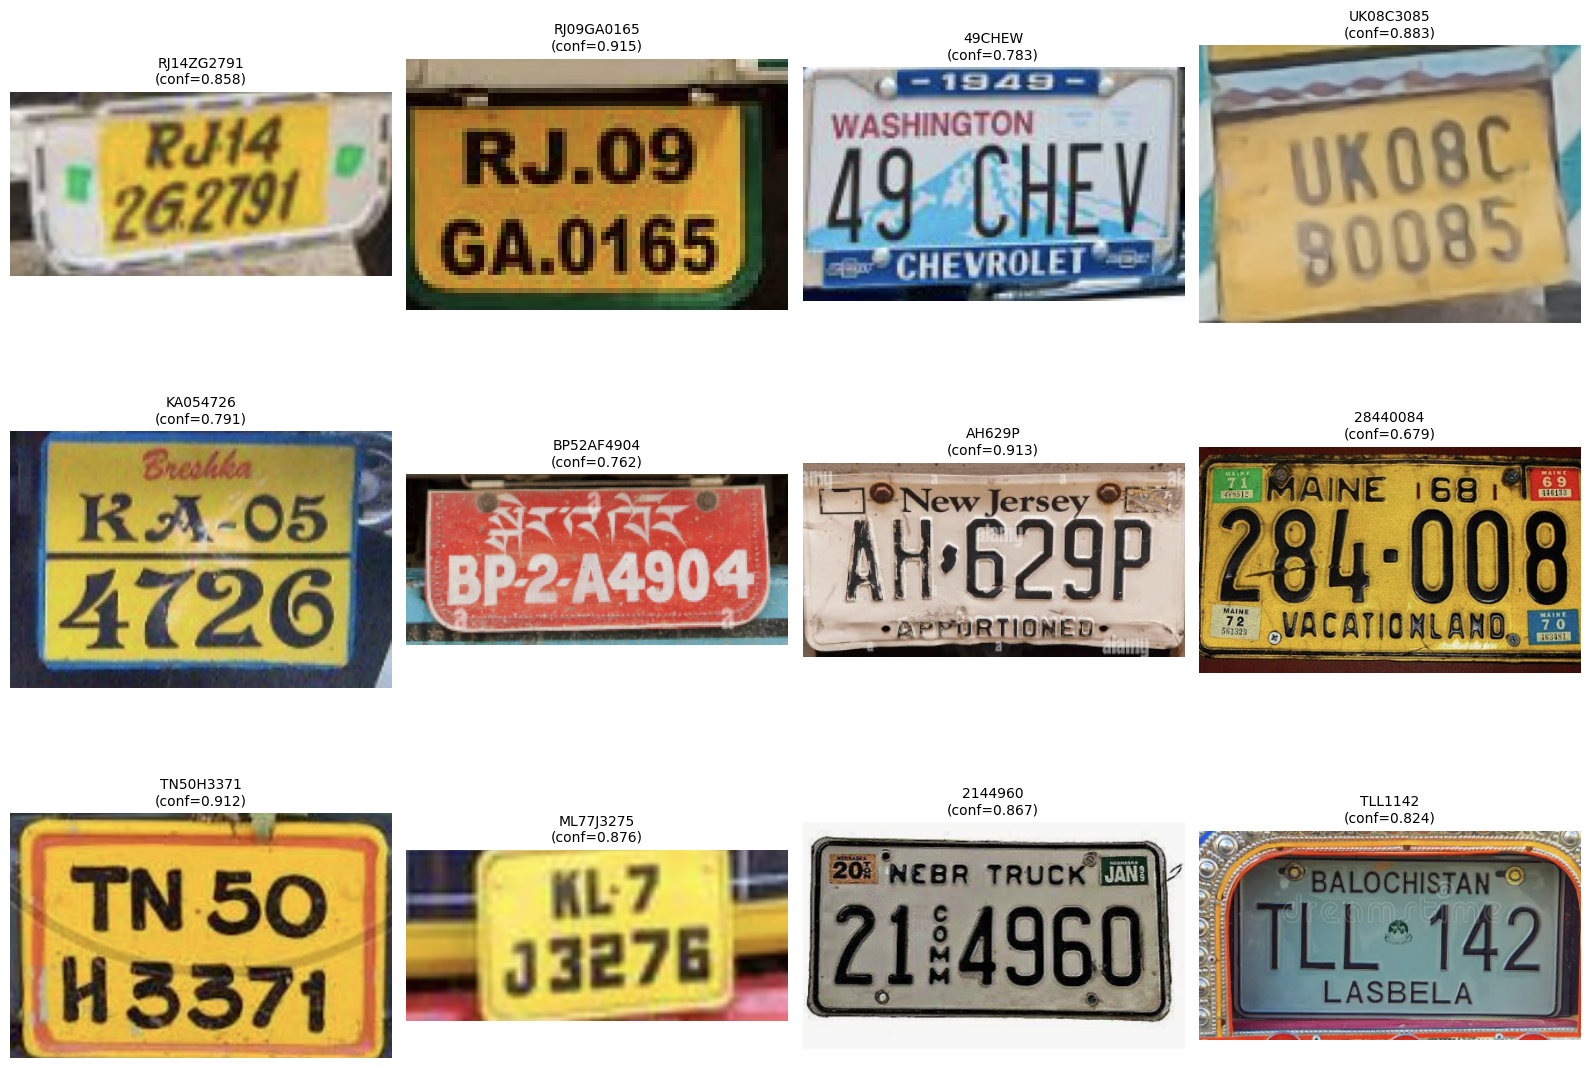

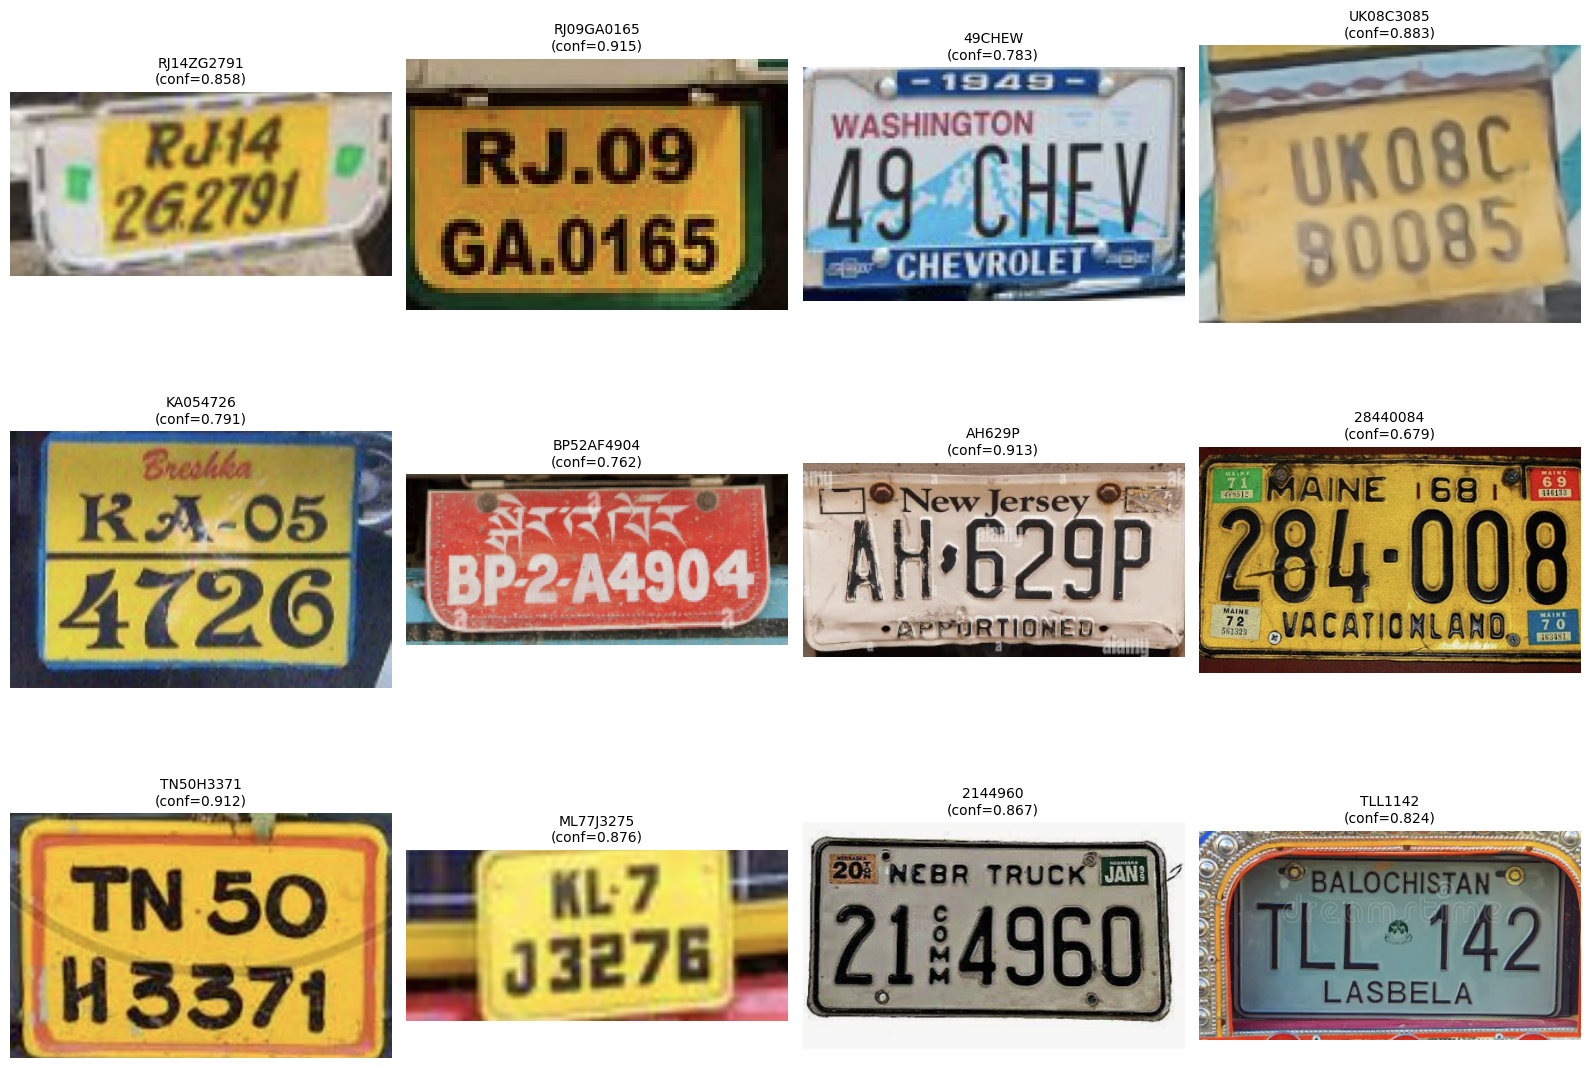

In [3]:
from pathlib import Path

def predict_and_plot_all(folder_path, ckpt_path='parseq_ctc.pt', device='cpu'):
    """
    Predicts and displays all images in a folder.
    
    Args:
        folder_path (str): Path to folder containing images.
        ckpt_path (str): Path to the trained model checkpoint.
        device (str, optional): 'cuda', 'mps', or 'cpu'. Auto-detected if None.
    """
    # Load model once
    ck = torch.load(ckpt_path, map_location=device, weights_only=True)
    cfg = Config(**ck["config"])
    model = PARSeqCTC(cfg).to(device)
    model.load_state_dict(ck["model"])
    model.eval()
    
    # Get all image files (common formats)
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    folder = Path(folder_path)
    image_files = [f for f in folder.iterdir() if f.suffix.lower() in image_extensions]
    
    if not image_files:
        print(f"No images found in {folder_path}")
        return
    
    print(f"Found {len(image_files)} images. Processing...")
    
    # Process images and display in a grid
    n_cols = min(4, len(image_files))
    n_rows = (len(image_files) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for idx, img_path in enumerate(image_files):
        try:
            # Read and preprocess
            img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
            if img_bgr is None:
                print(f"Could not read: {img_path.name}")
                continue
                
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            x = preprocess(img_rgb, cfg).unsqueeze(0).to(device)
            
            # Predict
            with torch.no_grad():
                texts, confs = model.predict(x)
            
            pred_text = texts[0]
            conf = confs[0]
            
            # Display
            ax = axes[idx]
            ax.imshow(img_rgb)
            ax.axis('off')
            ax.set_title(f"{pred_text}\n(conf={conf:.3f})", fontsize=10)
            
            print(f"{img_path.name:20} -> {pred_text:15} (conf={conf:.3f})")
            
        except Exception as e:
            print(f"Error processing {img_path.name}: {e}")
    
    # Hide unused subplots
    for idx in range(len(image_files), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    return fig

# Usage:
# Uncomment to run:
predict_and_plot_all('/Users/rzt/Downloads/truck plates', 'parseq_ctc_real_simple.pt') #'/Users/rzt/Downloads/ss_licence', '/Users/rzt/Downloads/truck plates'